In [ ]:
!pip install opendatasets --quiet
import opendatasets as od

# Replace this with your Kaggle dataset URL
dataset_url = 'https://www.kaggle.com/datasets/thoughtvector/customer-support-on-twitter'

# This will prompt for your kaggle.json credentials
od.download(dataset_url)

# Typically the data is downloaded into a folder named after the dataset
import pandas as pd
df = pd.read_csv('/content/customer-support-on-twitter/twcs/twcs.csv')

Skipping, found downloaded files in "./customer-support-on-twitter" (use force=True to force download)


In [ ]:
df.shape

(2811774, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2811774 entries, 0 to 2811773
Data columns (total 7 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   tweet_id                 int64  
 1   author_id                object 
 2   inbound                  bool   
 3   created_at               object 
 4   text                     object 
 5   response_tweet_id        object 
 6   in_response_to_tweet_id  float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 131.4+ MB


In [ ]:
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [ ]:
#show all the text
pd.set_option('display.max_colwidth', None)
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further assist.,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your profile.,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


cleaning the data

In [ ]:
# 1. Keep only customer tweets (inbound = True)
df = df[df['inbound'] == True].copy()

# 2. Drop rows with missing text
df = df.dropna(subset=['text'])

In [ ]:
import re
# 3. Basic text cleaning helper function
def clean_tweet(text):
    text = str(text)
    text = text.lower()                     # lowercase
    text = re.sub(r'http\S+', '', text)     # remove URLs
    text = re.sub(r'@\w+', '', text)        # remove @mentions
    text = re.sub(r'#', '', text)           # remove hash symbols (keep words)
    text = re.sub(r'[^a-zA-Z0-9\s!?.]', '', text)  # keep only alphanumeric, space, ! ? .
    text = re.sub(r'\s+', ' ', text).strip()       # collapse multiple spaces
    return text

In [ ]:
df['cleaned_text'] = df['text'].apply(clean_tweet)

# 4. (Optional) Filter out very short tweets (e.g., < 3 chars) if they are noise
df = df[df['cleaned_text'].str.len() >= 3]

In [ ]:
# 5. Reset index
df = df.reset_index(drop=True)

# 6. Organized Preview
display(df[['text', 'cleaned_text']].head(20))

,text,cleaned_text
0,@sprintcare and how do you propose we do that,and how do you propose we do that
1,@sprintcare I have sent several private messages and no one is responding as usual,i have sent several private messages and no one is responding as usual
2,@sprintcare I did.,i did.
3,@sprintcare is the worst customer service,is the worst customer service
4,@sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯,you gonna magically change your connectivity for me and my whole family ?
5,@sprintcare Since I signed up with you....Since day 1,since i signed up with you....since day 1
6,"@115714 y’all lie about your “great” connection. 5 bars LTE, still won’t load something. Smh.",yall lie about your great connection. 5 bars lte still wont load something. smh.
7,"@115714 whenever I contact customer support, they tell me I have shortcode enabled on my account, but I have never in the 4 years I've tried https://t.co/0G98RtNxPK",whenever i contact customer support they tell me i have shortcode enabled on my account but i have never in the 4 years ive tried
8,@Ask_Spectrum Would you like me to email you a copy of one since Spectrum is not updating your training?,would you like me to email you a copy of one since spectrum is not updating your training?
9,@Ask_Spectrum I received this from your corporate office would you like a copy?,i received this from your corporate office would you like a copy?


In [ ]:
!pip install vaderSentiment

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def urgent(original_text, cleaned_text):
    score = 0

    # Caps ratio from ORIGINAL text (not lowercased)
    caps_ratio = sum(1 for c in original_text if c.isupper()) / max(len(original_text), 1)
    if caps_ratio > 0.2:
        score += 1

    # Other signals from cleaned_text (lowercased)
    if any(w in cleaned_text for w in ['refund','broken','cancel']):
        score += 1

    if cleaned_text.count('!') >= 1:  # exclamation count works even after lowercasing? '!' is not letter, remains.
        score += 1

    # Sentiment (works fine with lowercased)
    sentiment = analyzer.polarity_scores(cleaned_text)['compound']
    if sentiment >= 0:
        return False
    if sentiment < -0.3:
        score += 1

    # Length signals (same with or without case)
    if len(cleaned_text) < 40:
        score += 1
    if len(cleaned_text.split()) < 3:
        score += 1

    return score >= 3

We increased the urgency threshold from 2 to 3 after observing false positives on short neutral responses. This reduces recall slightly but improves precision

In [ ]:
df['is_urgent'] = df.apply(lambda row: urgent(row['text'], row['cleaned_text']), axis=1)

In [ ]:
#show the shape of original vs is_urgent  true
df.shape, df[df['is_urgent'] == True].shape

((1511912, 9), (15337, 9))

In [ ]:
original_shape = df.shape[0]  # total tickets
urgent_count = df['is_urgent'].sum()
urgent_pct = (urgent_count / original_shape) * 100

print(f"Total tickets: {original_shape}")
print(f"Urgent tickets: {urgent_count} ({urgent_pct:.1f}%)")

Total tickets: 1511912
Urgent tickets: 15337 (1.0%)


trying updated function

In [ ]:
def urgent_v2(original_text, cleaned_text):
    score = 0

    # Keywords (use cleaned_text, already lowercased)
    if any(w in cleaned_text for w in ['refund','broken','cancel','down','help','issue','problem','error']):
        score += 1

    # Sentiment (use cleaned_text)
    if analyzer.polarity_scores(cleaned_text)['compound'] >= 0:
        return False
    if analyzer.polarity_scores(cleaned_text)['compound'] < -0.2:
        score += 1

    # Exclamation count (use cleaned_text – '!' remains unchanged)
    if cleaned_text.count('!') >= 1:
        score += 1

    # Caps ratio (use original_text – case sensitive)
    caps_ratio = sum(1 for c in original_text if c.isupper()) / max(len(original_text), 1)
    if caps_ratio > 0.1:
        score += 1

    # Short text (use cleaned_text)
    if len(cleaned_text) < 50:
        score += 1

    # Question mark (use cleaned_text)
    if '?' in cleaned_text:
        score += 1

    # Urgent if at least one signal
    return score >= 2

# Apply to create new column
df['is_urgent_v2'] = df.apply(lambda row: urgent_v2(row['text'], row['cleaned_text']), axis=1)

In [ ]:
df[df['is_urgent'] == True].head(10)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,cleaned_text,is_urgent
124,322,115791,True,Wed Nov 01 01:47:45 +0000 2017,@XboxSupport This is what's on my screen? Not sure if it's Xbox side or my5 side that's broken? Last time it was my5 as had to call head office about it! https://t.co/jnMIVOlNbS,NaN,321.0,this is whats on my screen? not sure if its xbox side or my5 side thats broken? last time it was my5 as had to call head office about it!,True
201,669,115844,True,Tue Oct 31 22:21:12 +0000 2017,@AmazonHelp I just said it's been sorted! I've been refunded! I'm just not impressed with the service any more.,NaN,668.0,i just said its been sorted! ive been refunded! im just not impressed with the service any more.,True
279,844,115886,True,Wed Nov 01 05:50:43 +0000 2017,@Delta Even #worse 😜,"845,846",842.0,even worse,True
326,1068,115911,True,Tue Oct 31 22:19:12 +0000 2017,@115910 No sir! You can still preorder at https://t.co/E7pnnCVItW *JoanO,1067,1069.0,no sir! you can still preorder at joano,True
688,1899,116137,True,Tue Oct 31 22:26:49 +0000 2017,Is this a trick? No NBC WPTV or ABC WPBF in PSL @115900 this afternoon! Why these 2 channels?,1897,NaN,is this a trick? no nbc wptv or abc wpbf in psl this afternoon! why these 2 channels?,True
949,2494,116299,True,Wed Nov 01 02:40:51 +0000 2017,"@115877 AND NOW, I CAN'T EVEN REORDER BECAUSE THE RESTAURANT IS CLOSED!!!!!!!!!!!!!!!!!!!!!!!!!! UBER EATS UBER SUCKS.",2493,NaN,and now i cant even reorder because the restaurant is closed!!!!!!!!!!!!!!!!!!!!!!!!!! uber eats uber sucks.,True
1540,3791,116631,True,Sat Nov 25 23:47:47 +0000 2017,@115817 WHY DID YOU MAKE ME PAY TO CHANGE MY DELIVERY DATE THEN DISREGARD THE CHANGED DATE AND DELIVERED IT ANYAYS?????!!?!!?! 😡🤬,3790,NaN,why did you make me pay to change my delivery date then disregard the changed date and delivered it anyays?????!!?!!?!,True
1803,4532,116773,True,Tue Oct 31 22:30:47 +0000 2017,@115790 @XboxSupport whats the story with broken pro clubs? @116774,4531,NaN,whats the story with broken pro clubs?,True
1914,4823,116842,True,Sat Nov 25 20:27:30 +0000 2017,I! Fucking! Hate! Wells! Fargo!,4822,NaN,i! fucking! hate! wells! fargo!,True
2402,5950,117132,True,Tue Oct 31 23:04:28 +0000 2017,@AirAsiaSupport Booking no YIUBPF. Thanks.,5948,5952.0,booking no yiubpf. thanks.,True


In [ ]:
df[df['is_urgent_v2'] == True].head(10)

,text,cleaned_text,is_urgent,is_urgent_v2
3,@sprintcare is the worst customer service,is the worst customer service,False,True
12,actually that's a broken link you sent me and incorrect information https://t.co/V4yfrHR8VI,actually thats a broken link you sent me and incorrect information,False,True
15,"@VerizonSupport I finally got someone that helped me, thanks!",i finally got someone that helped me thanks!,False,True
18,@VerizonSupport What else can I provide? They refuse to help me because they cannot validate the account...,what else can i provide? they refuse to help me because they cannot validate the account...,False,True
20,@115722 MD. And this was sent to the wrong address https://t.co/dMQ1WZXJOk,md. and this was sent to the wrong address,False,True
27,@VerizonSupport Yep,yep,False,True
28,@VerizonSupport Cuts out every 20 minutes this is ridiculous,cuts out every 20 minutes this is ridiculous,False,True
29,@115722 is the worst ISP I’ve ever had,is the worst isp ive ever had,False,True
30,.@VerizonSupport @115725 @115726 &gt;All of VERIZON IS DOWN&lt;\nWhen can we expect a fix ?,. gtall of verizon is downlt when can we expect a fix ?,False,True
33,@ChipotleTweets @28 \nI don't fit in my Veggie Burrito costume #Halloween https://t.co/7tJDVpzLWn,i dont fit in my veggie burrito costume halloween,False,True


In [ ]:
original_shape = df.shape[0]                 # total number of rows (tickets)
urgent_count_v2 = df['is_urgent_v2'].sum()   # counts True as 1, False as 0
urgent_pct = (urgent_count_v2 / original_shape) * 100

print(f"Total tickets: {original_shape}")
print(f"Urgent tickets: {urgent_count_v2} ({urgent_pct:.1f}%)")

Total tickets: 1511912
Urgent tickets: 282649 (18.7%)


In [ ]:
#drop unecessery columns
df.drop(['created_at', 'tweet_id', 'author_id', 'inbound', 'response_tweet_id', 'in_response_to_tweet_id'], axis=1, errors='ignore', inplace=True)
df.head(20)

,text,cleaned_text,is_urgent,is_urgent_v2
0,@sprintcare and how do you propose we do that,and how do you propose we do that,False,False
1,@sprintcare I have sent several private messages and no one is responding as usual,i have sent several private messages and no one is responding as usual,False,False
2,@sprintcare I did.,i did.,False,False
3,@sprintcare is the worst customer service,is the worst customer service,False,True
4,@sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯,you gonna magically change your connectivity for me and my whole family ?,False,False
5,@sprintcare Since I signed up with you....Since day 1,since i signed up with you....since day 1,False,False
6,"@115714 y’all lie about your “great” connection. 5 bars LTE, still won’t load something. Smh.",yall lie about your great connection. 5 bars lte still wont load something. smh.,False,False
7,"@115714 whenever I contact customer support, they tell me I have shortcode enabled on my account, but I have never in the 4 years I've tried https://t.co/0G98RtNxPK",whenever i contact customer support they tell me i have shortcode enabled on my account but i have never in the 4 years ive tried,False,False
8,@Ask_Spectrum Would you like me to email you a copy of one since Spectrum is not updating your training?,would you like me to email you a copy of one since spectrum is not updating your training?,False,False
9,@Ask_Spectrum I received this from your corporate office would you like a copy?,i received this from your corporate office would you like a copy?,False,False


In [ ]:
# Calculate word frequencies for Urgent (v1)
urgent_df = df[df['is_urgent'] == True]
urgent_words = ' '.join(urgent_df['cleaned_text']).split()
urgent_freq = pd.Series(urgent_words).value_counts().head(50).reset_index()
urgent_freq.columns = ['Word_Urgent_v1', 'Count_v1']

# Calculate word frequencies for Urgent (v2)
urgent_v2_df = df[df['is_urgent_v2'] == True]
urgent_v2_words = ' '.join(urgent_v2_df['cleaned_text']).split()
urgent_v2_freq = pd.Series(urgent_v2_words).value_counts().head(50).reset_index()
urgent_v2_freq.columns = ['Word_Urgent_v2', 'Count_v2']

# Calculate word frequencies for Not Urgent (using v2 for comparison)
not_urgent_df = df[df['is_urgent_v2'] == False]
not_urgent_words = ' '.join(not_urgent_df['cleaned_text']).split()
not_urgent_freq = pd.Series(not_urgent_words).value_counts().head(50).reset_index()
not_urgent_freq.columns = ['Word_Not_Urgent', 'Count_Not_Urgent']

# Combine for display
comparison_df = pd.concat([urgent_freq, urgent_v2_freq, not_urgent_freq], axis=1)
display(comparison_df.head(50))

,Word_Urgent_v1,Count_v1,Word_Urgent_v2,Count_v2,Word_Not_Urgent,Count_Not_Urgent
0,i,6508,i,158920,i,618854
1,to,5971,to,157717,to,612209
2,the,5493,the,155278,the,600400
3,my,4188,a,104110,a,384939
4,and,4077,and,99660,my,354953
5,a,4068,my,97392,and,351319
6,is,3244,is,88081,for,269317
7,you,2925,you,64775,is,263932
8,for,2676,for,62707,you,263781
9,no,2318,no,58033,it,240358


In [ ]:
# Concatenate side-by-side
comparison_df = pd.concat([urgent_freq, not_urgent_freq], axis=1)
display(comparison_df.head(50))

In [ ]:
#import pandas as pd
#from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
#analyzer = SentimentIntensityAnalyzer()

def add_engineered_features(df):
    # Basic counts
    df['text_length'] = df['cleaned_text'].str.len()
    df['word_count'] = df['cleaned_text'].str.split().str.len()
    df['exclamation_count'] = df['cleaned_text'].str.count('!')
    df['question_count'] = df['cleaned_text'].str.count('\?')

    # Caps ratio (from original text, not cleaned)
    df['caps_ratio'] = df['text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)),1))

    # Sentiment score
    df['sentiment_score'] = df['cleaned_text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

    # Keyword flags (expand as needed)
    keywords = ['refund', 'broken', 'cancel', 'down', 'help', 'issue', 'problem', 'error']
    for kw in keywords:
        df[f'has_{kw}'] = df['cleaned_text'].str.contains(kw, case=False).astype(int)

    return df

# Apply the function
df = add_engineered_features(df)


<>:10: SyntaxWarning: invalid escape sequence '\?'
<>:10: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipykernel_6240/2281264012.py:10: SyntaxWarning: invalid escape sequence '\?'
  df['question_count'] = df['cleaned_text'].str.count('\?')


   text_length  word_count  exclamation_count  question_count  caps_ratio  \
0           33           8                  0               0    0.000000   
1           70          13                  0               0    0.012195   
2            6           2                  0               0    0.055556   
3           29           5                  0               0    0.000000   
4           73          13                  0               1    0.011236   

   sentiment_score  has_refund  is_urgent_v2  
0           0.0000           0         False  
1          -0.2960           0         False  
2           0.0000           0         False  
3          -0.6249           0          True  
4           0.0000           0         False  


In [ ]:
df.head()

,text,cleaned_text,is_urgent,is_urgent_v2,text_length,word_count,exclamation_count,question_count,caps_ratio,sentiment_score,has_refund,has_broken,has_cancel,has_down,has_help,has_issue,has_problem,has_error
0,@sprintcare and how do you propose we do that,and how do you propose we do that,False,False,33,8,0,0,0.000000,0.0000,0,0,0,0,0,0,0,0
1,@sprintcare I have sent several private messages and no one is responding as usual,i have sent several private messages and no one is responding as usual,False,False,70,13,0,0,0.012195,-0.2960,0,0,0,0,0,0,0,0
2,@sprintcare I did.,i did.,False,False,6,2,0,0,0.055556,0.0000,0,0,0,0,0,0,0,0
3,@sprintcare is the worst customer service,is the worst customer service,False,True,29,5,0,0,0.000000,-0.6249,0,0,0,0,0,0,0,0
4,@sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯,you gonna magically change your connectivity for me and my whole family ?,False,False,73,13,0,1,0.011236,0.0000,0,0,0,0,0,0,0,0


In [ ]:
df.shape[1]

18

In [ ]:
# Check the new columns
display(df[['text_length', 'word_count', 'exclamation_count', 'question_count',
                       'caps_ratio', 'sentiment_score', 'has_refund', 'has_broken',
                       'has_cancel', 'has_down', 'has_help', 'has_issue', 'has_problem', 'has_error']].head())

,text_length,word_count,exclamation_count,question_count,caps_ratio,sentiment_score,has_refund,has_broken,has_cancel,has_down,has_help,has_issue,has_problem,has_error
0,33,8,0,0,0.000000,0.0000,0,0,0,0,0,0,0,0
1,70,13,0,0,0.012195,-0.2960,0,0,0,0,0,0,0,0
2,6,2,0,0,0.055556,0.0000,0,0,0,0,0,0,0,0
3,29,5,0,0,0.000000,-0.6249,0,0,0,0,0,0,0,0
4,73,13,0,1,0.011236,0.0000,0,0,0,0,0,0,0,0


is_urgent_v2
False    1229263
True      282649
Name: count, dtype: int64
Urgent percentage: 18.7%


/tmp/ipykernel_6240/3390447735.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Urgent percentage: {urgent_counts[1]/len(df)*100:.1f}%")


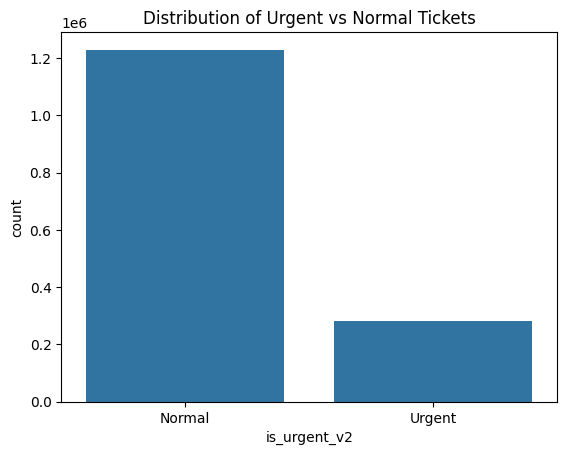

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Urgency distribution
urgent_counts = df['is_urgent_v2'].value_counts()
print(urgent_counts)
print(f"Urgent percentage: {urgent_counts[1]/len(df)*100:.1f}%")

# Bar plot
sns.countplot(x='is_urgent_v2', data=df)
plt.title('Distribution of Urgent vs Normal Tickets')
plt.xticks([0,1], ['Normal', 'Urgent'])
plt.show()

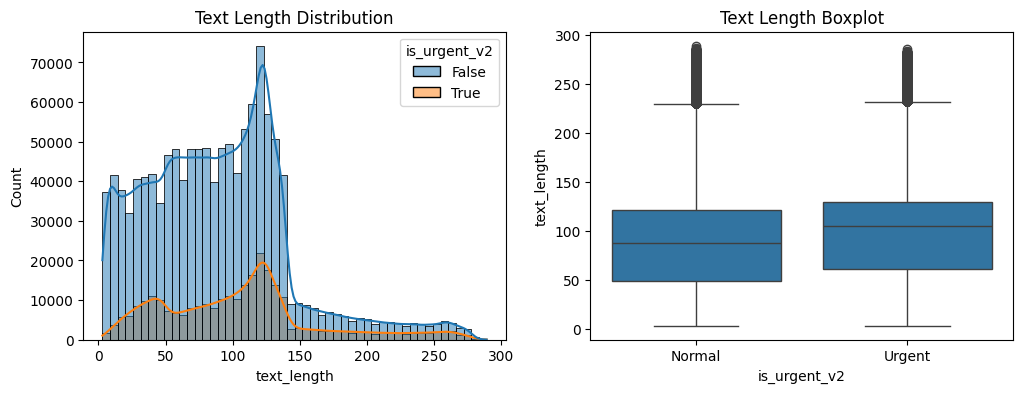

In [ ]:
#Text length distribution by urgency
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(data=df, x='text_length', hue='is_urgent_v2', bins=50, kde=True)
plt.title('Text Length Distribution')
plt.subplot(1,2,2)
sns.boxplot(x='is_urgent_v2', y='text_length', data=df)
plt.xticks([0,1], ['Normal', 'Urgent'])
plt.title('Text Length Boxplot')
plt.show()

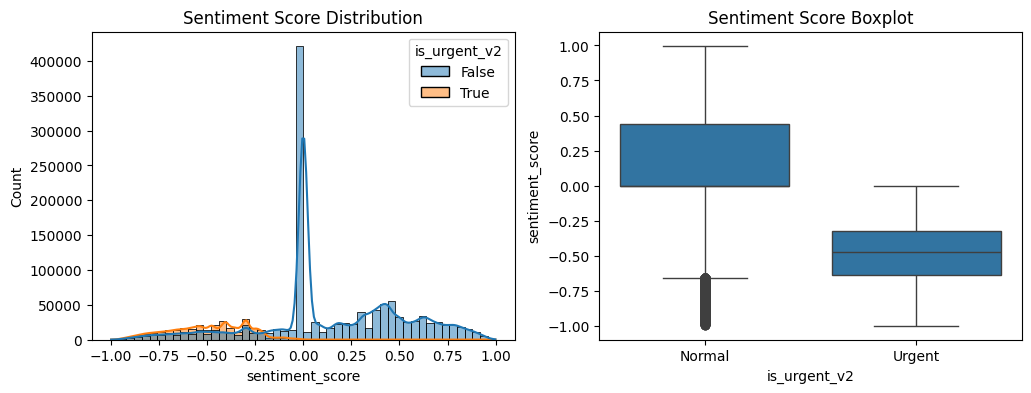

In [ ]:
#Sentiment score distribution by urgency
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(data=df, x='sentiment_score', hue='is_urgent_v2', bins=50, kde=True)
plt.title('Sentiment Score Distribution')
plt.subplot(1,2,2)
sns.boxplot(x='is_urgent_v2', y='sentiment_score', data=df)
plt.xticks([0,1], ['Normal', 'Urgent'])
plt.title('Sentiment Score Boxplot')
plt.show()

Percentage of tweets with sentiment score <= -0.3: 23.11%


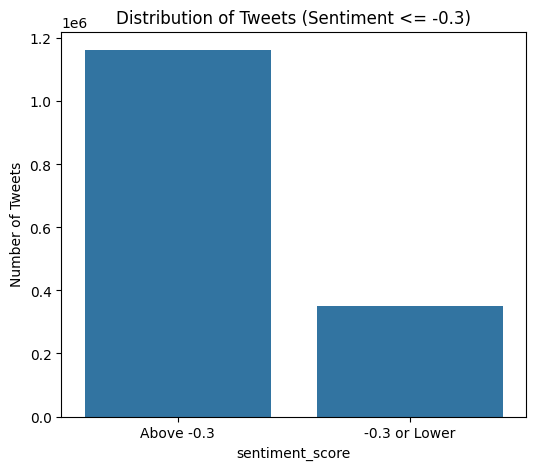

In [ ]:
# Calculate the percentage of tweets with sentiment <= -0.3
threshold = -0.3
low_sentiment_mask = df['sentiment_score'] <= threshold
low_sentiment_pct = low_sentiment_mask.mean() * 100

print(f"Percentage of tweets with sentiment score <= {threshold}: {low_sentiment_pct:.2f}%")

# Visualization
plt.figure(figsize=(6, 5))
sns.countplot(x=low_sentiment_mask)
plt.title(f'Distribution of Tweets (Sentiment <= {threshold})')
plt.xticks([0, 1], [f'Above {threshold}', f'{threshold} or Lower'])
plt.ylabel('Number of Tweets')
plt.show()

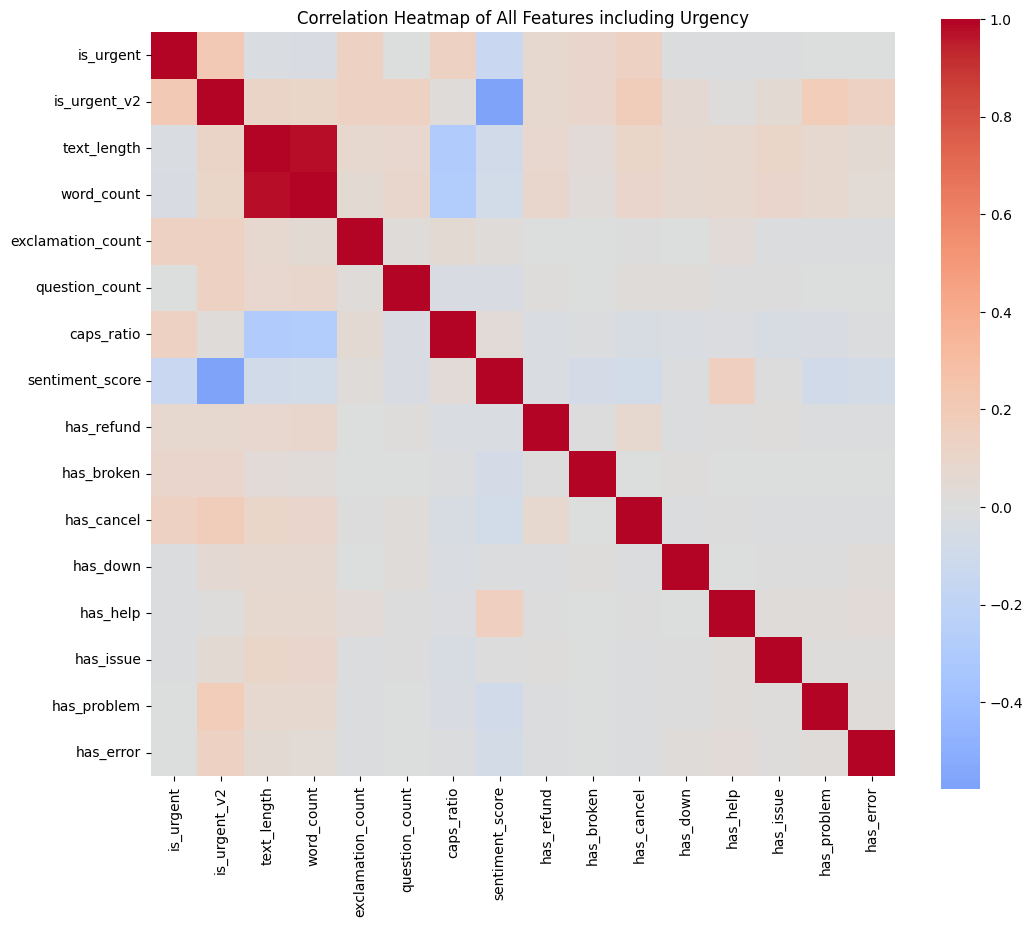

Correlations with is_urgent_v2:
is_urgent_v2         1.000000
is_urgent            0.211115
has_problem          0.181299
has_cancel           0.176009
has_error            0.140993
question_count       0.134255
exclamation_count    0.134120
text_length          0.112876
word_count           0.107299
has_broken           0.099501
has_refund           0.075796
has_down             0.057607
has_issue            0.055768
caps_ratio           0.019004
has_help             0.012487
sentiment_score     -0.577935
Name: is_urgent_v2, dtype: float64


In [ ]:
# Select numeric and boolean columns (to include is_urgent_v2)
numeric_cols = df.select_dtypes(include=['number', 'bool']).columns

# Calculate correlation
feature_corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(feature_corr, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of All Features including Urgency')
plt.show()

# Show top correlations with is_urgent_v2
if 'is_urgent_v2' in feature_corr.columns:
    corr_with_target = feature_corr['is_urgent_v2'].sort_values(ascending=False)
    print("Correlations with is_urgent_v2:")
    print(corr_with_target)
else:
    print("is_urgent_v2 not found in correlation matrix.")

In [ ]:
# Set a correlation threshold
threshold = 0.05

# Identify features with correlation higher than the threshold
# We take the absolute value to include negative correlations (like sentiment)
relevant_features = corr_with_target[abs(corr_with_target) >= threshold].index.tolist()

# Remove the target itself from the feature list
if 'is_urgent_v2' in relevant_features:
    relevant_features.remove('is_urgent_v2')

print(f"Features retained (correlation >= {threshold}):")
print(relevant_features)

# Create the filtered feature matrix
X_filtered = df[relevant_features]
print(f"\nNew shape of X: {X_filtered.shape}")

Features retained (correlation >= 0.05):
['is_urgent', 'has_problem', 'has_cancel', 'has_error', 'question_count', 'exclamation_count', 'text_length', 'word_count', 'has_broken', 'has_refund', 'has_down', 'has_issue', 'sentiment_score']

New shape of X: (1511912, 13)


In [ ]:
X_filtered

,is_urgent,has_problem,has_cancel,has_error,question_count,exclamation_count,text_length,word_count,has_broken,has_refund,has_down,has_issue,sentiment_score
0,False,0,0,0,0,0,33,8,0,0,0,0,0.0000
1,False,0,0,0,0,0,70,13,0,0,0,0,-0.2960
2,False,0,0,0,0,0,6,2,0,0,0,0,0.0000
3,False,0,0,0,0,0,29,5,0,0,0,0,-0.6249
4,False,0,0,0,1,0,73,13,0,0,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1511907,False,0,0,1,1,0,104,21,0,0,0,0,0.2732
1511908,False,0,0,0,2,0,94,18,0,0,0,0,0.8053
1511909,False,0,0,0,1,4,78,14,0,0,0,0,-0.9255
1511910,False,0,0,0,0,0,114,26,0,0,0,0,0.4404


In [ ]:
#split into train val test
from sklearn.model_selection import train_test_split
X = X_filtered.drop('is_urgent', axis=1)
y = df['is_urgent_v2']
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [ ]:
X_train.head()

,has_problem,has_cancel,has_error,question_count,exclamation_count,text_length,word_count,has_broken,has_refund,has_down,has_issue,sentiment_score
97725,0,0,0,0,0,132,26,0,0,0,0,-0.8047
15463,0,0,0,1,0,33,7,0,0,0,0,0.0000
1460138,0,0,0,0,0,36,7,0,0,0,0,0.7430
71191,0,0,0,0,0,70,15,0,0,0,0,-0.2023
1453856,0,0,0,0,0,57,10,0,0,0,0,0.2382


In [ ]:
#check the shapes
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Urgent ratio in train: {y_train.mean():.3f}, val: {y_val.mean():.3f}, test: {y_test.mean():.3f}")

Train: (907147, 12), Val: (302382, 12), Test: (302383, 12)
Urgent ratio in train: 0.187, val: 0.187, test: 0.187


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Define models with basic parameters (you can tune later)
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                 eval_metric='logloss', random_state=42)
}

In [ ]:
# Train and evaluate on validation set
val_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_val_pred)
    val_results[name] = {'model': model, 'f1': f1}
    print(f"{name} - Validation F1: {f1:.4f}")
    print(classification_report(y_val, y_val_pred))
    print("-" * 50)


Logistic Regression - Validation F1: 0.7572
              precision    recall  f1-score   support

       False       0.98      0.89      0.93    245852
        True       0.65      0.91      0.76     56530

    accuracy                           0.89    302382
   macro avg       0.81      0.90      0.84    302382
weighted avg       0.92      0.89      0.90    302382

--------------------------------------------------
Random Forest - Validation F1: 0.9517
              precision    recall  f1-score   support

       False       0.99      0.99      0.99    245852
        True       0.96      0.94      0.95     56530

    accuracy                           0.98    302382
   macro avg       0.98      0.97      0.97    302382
weighted avg       0.98      0.98      0.98    302382

--------------------------------------------------
XGBoost - Validation F1: 0.9576
              precision    recall  f1-score   support

       False       0.99      1.00      0.99    245852
        True       0.

In [ ]:
# Select best model based on validation F1
best_model_name = max(val_results, key=lambda x: val_results[x]['f1'])
best_model = val_results[best_model_name]['model']
print(f"Best model on validation: {best_model_name} (F1={val_results[best_model_name]['f1']:.4f})")


Best model on validation: XGBoost (F1=0.9576)


In [ ]:
# Evaluate on test set
y_test_pred = best_model.predict(X_test)
test_f1 = f1_score(y_test, y_test_pred)
print(f"\nTest set F1 for {best_model_name}: {test_f1:.4f}")
print(classification_report(y_test, y_test_pred))


Test set F1 for XGBoost: 0.9571
              precision    recall  f1-score   support

       False       0.99      1.00      0.99    245853
        True       0.98      0.94      0.96     56530

    accuracy                           0.98    302383
   macro avg       0.98      0.97      0.97    302383
weighted avg       0.98      0.98      0.98    302383



In [ ]:
# Predict on training set
y_train_pred = best_model.predict(X_train)
train_f1 = f1_score(y_train, y_train_pred)

print(f"Training F1: {train_f1:.4f}")
print(f"Validation F1: {val_results['XGBoost']['f1']:.4f}")
print(f"Test F1: {test_f1:.4f}")

Training F1: 0.9588
Validation F1: 0.9576
Test F1: 0.9571


In [ ]:
import pandas as pd
import numpy as np

# Get the feature names directly from the training set to ensure exact match
model_features = X_train.columns.tolist()

# Manual input data matching the model_features list (dropping 'is_urgent')
# Data: problem=0, cancel=0, error=0, quest=0, excl=3, len=45, words=6, broken=1, refund=0, down=0, issue=0, sentiment=-0.7184
test_row = pd.DataFrame([[
    1, 1, 1, 1, 4, 200, 50, 1, 1, 1, 1, 0
]], columns=model_features)

# Predict
prediction = best_model.predict(test_row)[0]
probability = best_model.predict_proba(test_row)[0][1]

print(f"Prediction: {'Urgent' if prediction == 1 else 'Normal'}")
print(f"Urgency probability: {probability:.3f}")

Prediction: Normal
Urgency probability: 0.017


/tmp/ipykernel_6240/3247361445.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_importances.values, y=xgb_importances.index, ax=axes[0], palette='viridis')
/tmp/ipykernel_6240/3247361445.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.values, y=rf_importances.index, ax=axes[1], palette='magma')
/tmp/ipykernel_6240/3247361445.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lr_coeffs.values, y=lr_coeffs.index, ax=axes[2], palette='coolwarm')


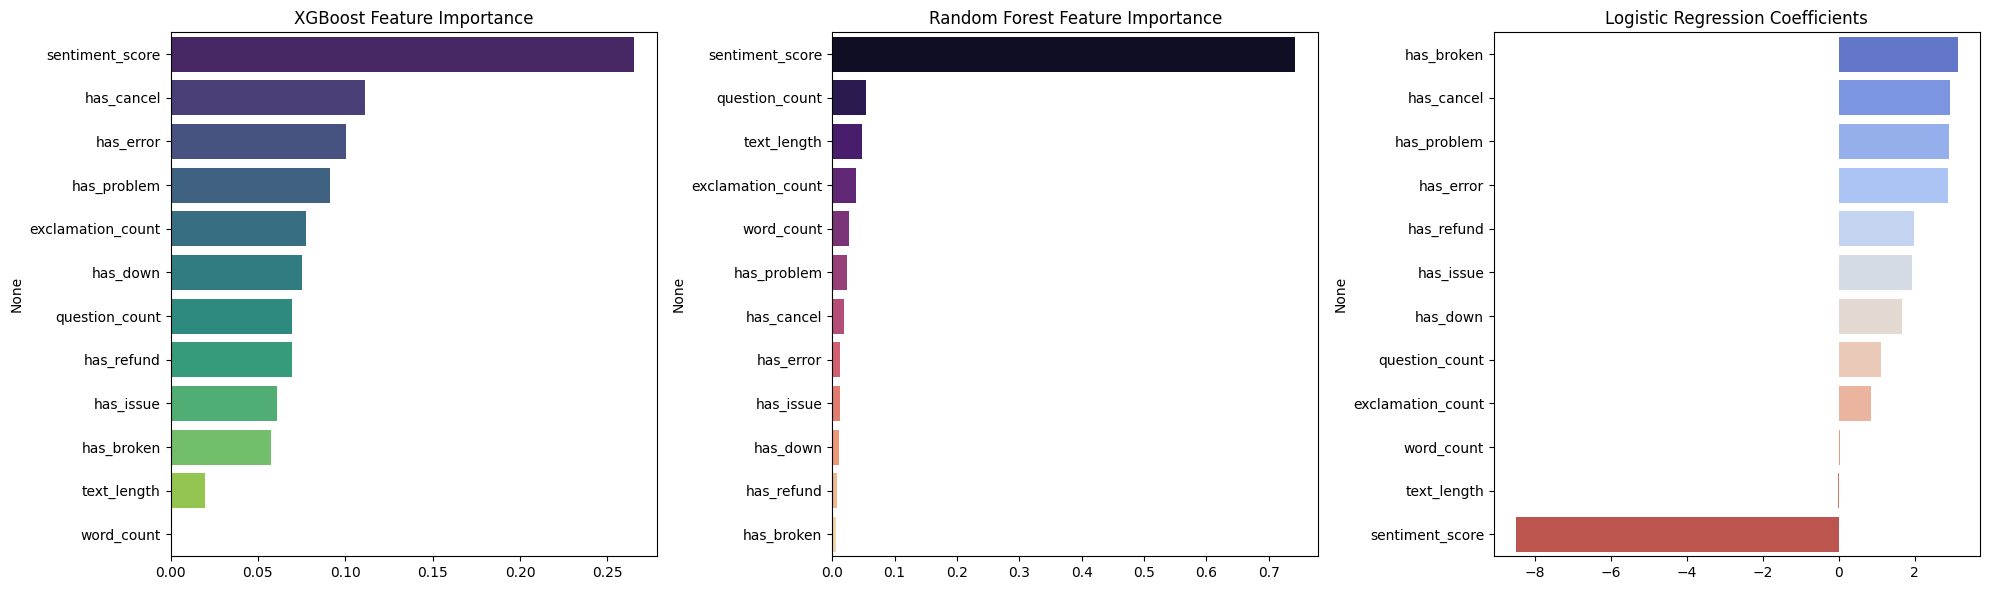

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Tree-Based Importance (XGBoost and Random Forest)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# XGBoost Importance
xgb_model = models['XGBoost']
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=xgb_importances.values, y=xgb_importances.index, ax=axes[0], palette='viridis')
axes[0].set_title('XGBoost Feature Importance')

# Random Forest Importance
rf_model = models['Random Forest']
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=rf_importances.values, y=rf_importances.index, ax=axes[1], palette='magma')
axes[1].set_title('Random Forest Feature Importance')

# 2. Linear Model Coefficients (Logistic Regression)
lr_model = models['Logistic Regression']
# Note: Coefficients represent importance only if features are on similar scales
lr_coeffs = pd.Series(lr_model.coef_[0], index=X_train.columns).sort_values(ascending=False)
sns.barplot(x=lr_coeffs.values, y=lr_coeffs.index, ax=axes[2], palette='coolwarm')
axes[2].set_title('Logistic Regression Coefficients')

plt.tight_layout()
plt.show()

i think here we can only rely on the sentiment analysis column

              feature  importance
11    sentiment_score    0.264923
1          has_cancel    0.111485
2           has_error    0.100477
0         has_problem    0.091146
4   exclamation_count    0.077679
9            has_down    0.075500
3      question_count    0.069776
8          has_refund    0.069400
10          has_issue    0.060879
7          has_broken    0.057772
5         text_length    0.019938
6          word_count    0.001026


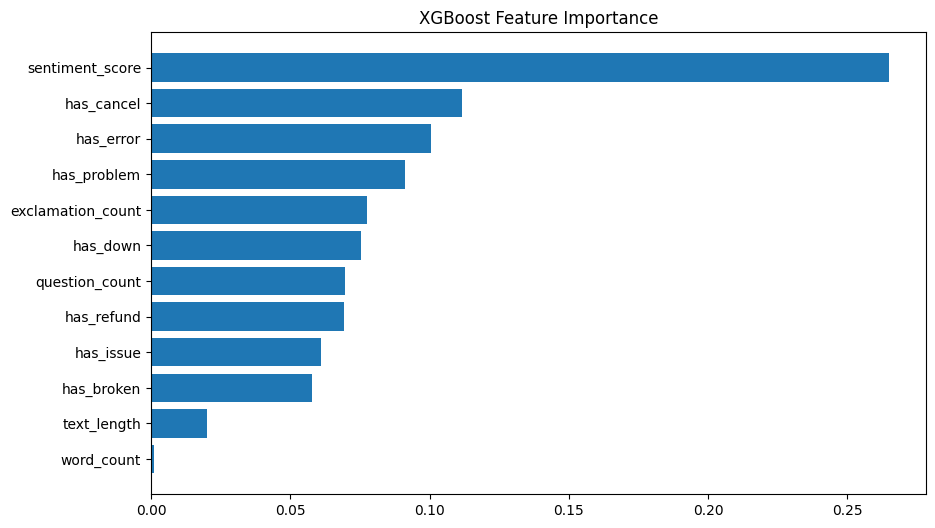

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Use X_train.columns to ensure feature names match the importance array length
importance = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
}).sort_values('importance', ascending=False)

print(feature_importance_df)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.show()

We removed features with importance below 0.02 because they contribute negligibly to predictions. This reduced model complexity without affecting F1 score.

In [ ]:
# Identify features to keep (importance >= 0.02)
features_to_keep = feature_importance_df[feature_importance_df['importance'] >= 0.02]['feature'].tolist()

print(f"Retaining {len(features_to_keep)} features: {features_to_keep}")

# Filter datasets
X_train_reduced = X_train[features_to_keep]
X_val_reduced = X_val[features_to_keep]
X_test_reduced = X_test[features_to_keep]

# Retrain XGBoost on reduced set
import xgboost as xgb
final_model = xgb.XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                                 eval_metric='logloss', random_state=42)
final_model.fit(X_train_reduced, y_train)

# Evaluate
from sklearn.metrics import f1_score, classification_report
y_val_pred = final_model.predict(X_val_reduced)
print(f"\nReduced Model Validation F1: {f1_score(y_val, y_val_pred):.4f}")
print(classification_report(y_val, y_val_pred))

Retaining 10 features: ['sentiment_score', 'has_cancel', 'has_error', 'has_problem', 'exclamation_count', 'has_down', 'question_count', 'has_refund', 'has_issue', 'has_broken']

Reduced Model Validation F1: 0.7979
              precision    recall  f1-score   support

       False       0.99      0.90      0.94    245852
        True       0.68      0.96      0.80     56530

    accuracy                           0.91    302382
   macro avg       0.84      0.93      0.87    302382
weighted avg       0.93      0.91      0.91    302382



In [ ]:
print("Original model expected features:", best_model.get_booster().feature_names)

Original model expected features: ['has_problem', 'has_cancel', 'has_error', 'question_count', 'exclamation_count', 'text_length', 'word_count', 'has_broken', 'has_refund', 'has_down', 'has_issue', 'sentiment_score']


In [ ]:
X_train_reduced.head()

,sentiment_score,has_cancel,has_error,has_problem,exclamation_count,has_down,question_count,has_refund,has_issue,has_broken
97725,-0.8047,0,0,0,0,0,0,0,0,0
15463,0.0000,0,0,0,0,0,1,0,0,0
1460138,0.7430,0,0,0,0,0,0,0,0,0
71191,-0.2023,0,0,0,0,0,0,0,0,0
1453856,0.2382,0,0,0,0,0,0,0,0,0


In [ ]:
# Features were previously filtered based on importance >= 0.02
# features_to_keep = ['sentiment_score', 'has_cancel', 'has_error', 'has_problem', 'exclamation_count', 'has_down', 'question_count', 'has_refund', 'has_issue', 'has_broken']

import xgboost as xgb
from sklearn.metrics import f1_score, classification_report

# Initialize and train the final XGBoost model on the reduced feature set
final_model = xgb.XGBClassifier(
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='logloss',
    random_state=42
)

final_model.fit(X_train_reduced, y_train)

# Final evaluation on the Test Set
y_test_pred = final_model.predict(X_test_reduced)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Final Model Test F1 Score: {test_f1:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

Final Model Test F1 Score: 0.7966

Classification Report (Test Set):
              precision    recall  f1-score   support

       False       0.99      0.90      0.94    245853
        True       0.68      0.96      0.80     56530

    accuracy                           0.91    302383
   macro avg       0.84      0.93      0.87    302383
weighted avg       0.93      0.91      0.91    302383



Final Model Feature Importances:
             Feature  Importance
0    sentiment_score    0.391978
4  exclamation_count    0.139611
6     question_count    0.105587
1         has_cancel    0.078319
3        has_problem    0.064494
7         has_refund    0.055071
2          has_error    0.048730
9         has_broken    0.041629
5           has_down    0.039728
8          has_issue    0.034854


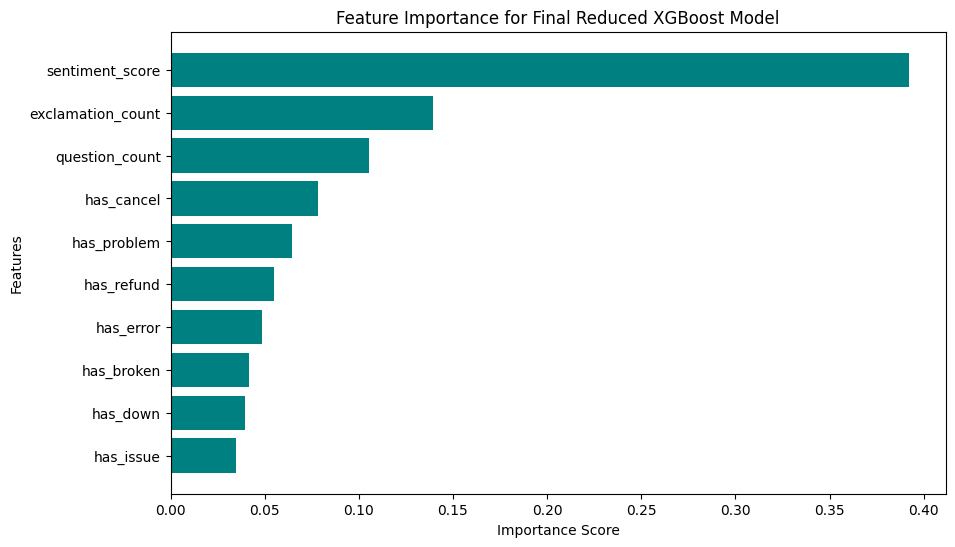

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get importance from the final model
importance = final_model.feature_importances_
features = X_train_reduced.columns

# Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importance})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

print("Final Model Feature Importances:")
print(feat_imp_df)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance for Final Reduced XGBoost Model')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
import pickle

# Define the filename for the exported model
model_filename = 'final_urgency_model.pkl'

# Save the final_model to a pickle file
with open(model_filename, 'wb') as file:
    pickle.dump(final_model, file)

print(f"Model successfully exported as {model_filename}")

Model successfully exported as final_urgency_model.pkl


In [ ]:
import pandas as pd
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def inference_preprocess(raw_text):
    # 1. Clean the text
    text = str(raw_text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s!?.]', '', text)
    cleaned_text = re.sub(r'\s+', ' ', text).strip()

    # 2. Extract specific features in the correct order for the final_model
    # Required: ['sentiment_score', 'has_cancel', 'has_error', 'has_problem', 'exclamation_count', 'has_down', 'question_count', 'has_refund', 'has_issue', 'has_broken']

    features = {
        'sentiment_score': analyzer.polarity_scores(cleaned_text)['compound'],
        'has_cancel': 1 if 'cancel' in cleaned_text else 0,
        'has_error': 1 if 'error' in cleaned_text else 0,
        'has_problem': 1 if 'problem' in cleaned_text else 0,
        'exclamation_count': cleaned_text.count('!'),
        'has_down': 1 if 'down' in cleaned_text else 0,
        'question_count': cleaned_text.count('?'),
        'has_refund': 1 if 'refund' in cleaned_text else 0,
        'has_issue': 1 if 'issue' in cleaned_text else 0,
        'has_broken': 1 if 'broken' in cleaned_text else 0
    }

    # Ensure the order matches exactly what final_model was trained on
    feature_order = ['sentiment_score', 'has_cancel', 'has_error', 'has_problem',
                     'exclamation_count', 'has_down', 'question_count',
                     'has_refund', 'has_issue', 'has_broken']

    return pd.DataFrame([features])[feature_order]

# Example usage:
# input_df = inference_preprocess("MY ORDER IS BROKEN HELP!!")
# prediction = final_model.predict(input_df)
# print("Urgent" if prediction[0] == 1 else "Normal")